### lesson \#16 by Storchak Vasyl

# task 'Replicate Simple recommender implementation'

**_NOTE:_**  im lazy for optional task XD

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

from scipy.io import loadmat

In [5]:
!which python3.12

/usr/bin/python3.12


In [3]:
print(platform.python_version())

3.12.11


In [6]:
#load dataset

In [8]:
mat = loadmat('ex8_movies.mat')

In [10]:
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Y', 'R'])


In [16]:
print(mat['Y']) # users
print(mat['R']) # reviews

[[5 4 0 ... 5 0 0]
 [3 0 0 ... 0 0 5]
 [4 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[1 1 0 ... 1 0 0]
 [1 0 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [17]:
# ctrl c v =)
def get_data():
    mat = loadmat('ex8_movies.mat') # returns dict - just select proper key to get necessary data
    Y = pd.DataFrame( mat['Y']) # value  vertical (axis 0):  movies 1682. Every row is for one movie , horizontal (axis 1): Users 943, every column is for one user  
    R = pd.DataFrame( mat['R']) #  flag of reviewed or not  vertical (axis 0):  movies 1682. Every row is for one movie , horizontal (axis 1): Users 943, every column is for one user  

    # convert to float to avoid issues with uint type  
    Y = Y.astype(float).values 
    R = R.astype(float).values

    return Y,R

In [19]:
Y, R = get_data()

In [20]:
print('Y.shape=', Y.shape)
print('Y[:5] =\n', Y[:5])
print('\nUnique values of Y:\n', set(Y.ravel()))

Y.shape= (1682, 943)
Y[:5] =
 [[5. 4. 0. ... 5. 0. 0.]
 [3. 0. 0. ... 0. 0. 5.]
 [4. 0. 0. ... 0. 0. 0.]
 [3. 0. 0. ... 0. 0. 0.]
 [3. 0. 0. ... 0. 0. 0.]]

Unique values of Y:
 {0.0, 1.0, 2.0, 3.0, 4.0, 5.0}


In [21]:
print('R.shape=', R.shape)
print('R[:5] =\n', R[:5])
print('\nUnique values of R:\n', set(R.ravel()))

R.shape= (1682, 943)
R[:5] =
 [[1. 1. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]

Unique values of R:
 {0.0, 1.0}


In [ ]:
# just note
# 943 user
# 1682 reviews
- | 1 2 3 4 5 ... <- users
---------------------------
1 | 1 0 0 1 1
2 | 1 1 1 0 0
3 | 0 1 ...
4 | 0 ...
5 | 1 ...
...
  ^
/ | \
  |
  |
reviews

In [27]:
# Collaborative Filtering Cost Functin
def J(Y, R, X,Theta, lambd): 
    '''
    params: 1d vector  of X and Theta 
    :return expression for cost function 
    '''
    assert(X.shape[1]==Theta.shape[0])
    h = X @ Theta 
    
    try: 
        assert(h.shape == Y.shape)
    except:
        print ('h.shape {} !=Y.shape {}'.format(h.shape, Y.shape) )
    J = 1/2 * np.sum(((h-Y) * R)**2) + lambd/2 * np.sum(X**2) + lambd/2 * np.sum(Theta**2)
    
    try: 
        assert(len(J.shape) == 0)
    except:
        print ('J is not raw number. J.shape = ', J.shape)
    return J

In [28]:
# Collaborative Filtering Cost Functin Gradient
def J_derivative(Y, R, X, Theta, num_movies, num_users, num_features, lambd): 
    # n_movies * n_users 
    cost_matr = (X @ Theta - Y) * R 
    X_grad = cost_matr @ Theta.T 
    Theta_grad = (cost_matr.T @ X).T
    
    try: 
        assert(X_grad.shape == X.shape)
        assert(Theta_grad.shape == Theta.shape)
    except:
        print ('Check gradient calculus')
        
    # Regularization part       
    X_grad  += lambd * X
    Theta_grad += lambd * Theta
    
    return X_grad, Theta_grad

In [29]:
# compute
def fit(Y, R, num_features=10,  alpha=0.0001, lambd=.01, eps=.1,  max_iter=1000, step=100, verbose=0):    
    num_movies,num_users = Y.shape
    
    if verbose: 
        print ('Running gradient descent with alpha= {}, lambda= {}, eps= {}, max_iter= {}'.format(
            alpha, lambd, eps, max_iter))
    #     X= params[:num_movies*num_features].reshape(num_movies,num_features)
    #     Theta = params[num_movies*num_features:].reshape(num_features,num_users)
    
    np.random.seed(2019)
    X = np.random.randn(num_movies, num_features)
    Theta = np.random.randn( num_features, num_users)
    J_hist = [-1] # used for keeping J values. Init with -1 to avoid 0 at first iter
    continue_iter = True # flag to continue next iter (grad desc step)
    iter_number = 0 # used for limit by max_iter

    while continue_iter:            
        # Do step of gradient descent    
        X_grad, Theta_grad = J_derivative(Y, R, X, Theta, num_movies, num_users, num_features, lambd)
        X = X - alpha * X_grad        
        Theta = Theta - alpha * Theta_grad
        
        # keep history of J values
        J_hist.append(
            J(Y, R, X, Theta, lambd))
        
        # check criteria of exit (finish grad desc)
        if iter_number > max_iter: # if limit succeeded
            continue_iter = False
            print('iter_number> max_iter')
        elif np.abs(J_hist[iter_number-1] - J_hist[iter_number]) < eps: # if accuracy is succeeded
            continue_iter = False
            print('J_hist[iter_number]={}'.format(J_hist[iter_number]))
            
        iter_number += 1
        
        if verbose and iter_number % step == 0:
            print('{}: {}'.format(iter_number, J_hist[iter_number-1]))
    
    return X,Theta, J_hist

In [30]:
X, Theta, J_hist = fit(Y, R, alpha=0.001, lambd=1, max_iter=2000, verbose=1)

Running gradient descent with alpha= 0.001, lambda= 1, eps= 0.1, max_iter= 2000
100: 46624.80715776309
200: 53775.991502524805
300: 43733.53486206348
400: 40831.75291750636
500: 39035.822781902076
600: 37814.29631650718
700: 36925.66574262506
800: 36251.94119779428
900: 35726.60793968343
1000: 35309.368362446825
1100: 34973.2854281251
1200: 34698.78959535303
1300: 34471.40237327723
1400: 34280.732546733365
1500: 34119.55379496762
1600: 33982.71680525658
1700: 33866.18531536781
1800: 33766.47660299338
1900: 33680.49797333296
2000: 33605.57713377487
iter_number> max_iter


In [31]:
# visualize cost function history
def draw_cost_changes(J_hist):
    J_hist = J_hist[1:]
    plt.figure()
    plt.scatter(np.arange(0, len(J_hist)), J_hist, s=20, marker='.', c='b')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')

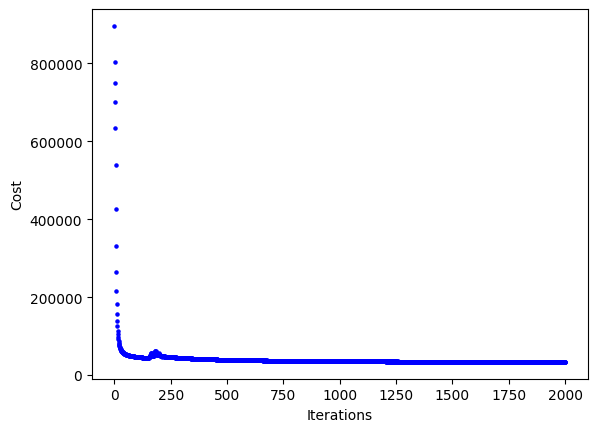

In [32]:
draw_cost_changes(J_hist)

In [34]:
# Predict missed values of training data 
pred = X @ Theta
pred

array([[3.63067147, 3.88666946, 2.40576999, ..., 4.54011846, 4.36029223,
        3.93326403],
       [2.80011248, 3.29577016, 2.53739175, ..., 3.17689721, 4.0113373 ,
        3.04035238],
       [3.06520486, 2.81648457, 3.93388444, ..., 2.72525932, 3.53337632,
        2.75231426],
       ...,
       [0.86845254, 0.72470642, 0.01049199, ..., 0.67518173, 0.55738831,
        0.8042484 ],
       [2.20769107, 2.10829064, 1.23490905, ..., 1.90791656, 2.12861293,
        1.78059828],
       [2.45855657, 2.27719474, 1.49320411, ..., 2.37037439, 1.95018702,
        1.16119517]])

In [35]:
# Evaluate the prediction

diff_train = (pred-Y) * R

# avoid those valueswhere R = 0 
diff_train_proivided = diff_train.ravel()[np.where(diff_train.ravel() != 0)]
print('Training:', np.abs(diff_train_proivided).max(), np.abs(diff_train_proivided).mean())

Training: 4.385953348630867 0.574793178988949


(array([2.0000e+01, 2.4900e+02, 8.5900e+02, 7.2740e+03, 3.6637e+04,
        4.0173e+04, 1.2578e+04, 1.9970e+03, 2.0700e+02, 6.0000e+00]),
 array([-4.38595335, -3.5459845 , -2.70601565, -1.86604681, -1.02607796,
        -0.18610911,  0.65385973,  1.49382858,  2.33379743,  3.17376628,
         4.01373512]),
 <BarContainer object of 10 artists>)

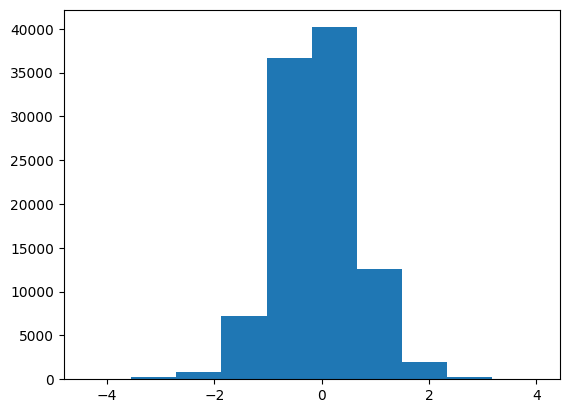

In [36]:
plt.hist(diff_train_proivided.ravel())

In [88]:
# thx teacher for file forgotten with names of films (i find with chatgpt XD )
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1', header=None, usecols=[0, 1], names=['item_id', 'title'])

In [89]:
movies

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
...,...,...
1677,1678,Mat' i syn (1997)
1678,1679,B. Monkey (1998)
1679,1680,Sliding Doors (1998)
1680,1681,You So Crazy (1994)


In [99]:
df_movie_names = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1', header=None, usecols=[1], names=['title'])

In [100]:
df_movie_names

,title
0,Toy Story (1995)
1,GoldenEye (1995)
2,Four Rooms (1995)
3,Get Shorty (1995)
4,Copycat (1995)
...,...
1677,Mat' i syn (1997)
1678,B. Monkey (1998)
1679,Sliding Doors (1998)
1680,You So Crazy (1994)


In [101]:
def build_my_raitings():
    my_ratings = np.zeros((1682, 1))
    # % Check the file movie_idx.txt for id of each movie in our dataset
    # % For example, Toy Story (1995) has ID 1, so to rate it "4", you can set

    my_ratings[0] = 4
    my_ratings[97] = 2
    my_ratings[6] = 3
    my_ratings[11]= 5
    my_ratings[53] = 4
    my_ratings[63]= 5
    my_ratings[65]= 3
    my_ratings[68] = 5
    my_ratings[182] = 4
    my_ratings[225] = 5
    my_ratings[354]= 5
    return my_ratings

my_ratings= build_my_raitings()

print ('\n\nNew user ratings:\n')
for i in range(len(my_ratings)):
    if my_ratings[i] > 0:
        print('Rated {} for {}\n'.format(int(my_ratings[i][0]), df_movie_names.iloc[i].values[0]))



New user ratings:

Rated 4 for Toy Story (1995)

Rated 3 for Twelve Monkeys (1995)

Rated 5 for Usual Suspects, The (1995)

Rated 4 for Outbreak (1995)

Rated 5 for Shawshank Redemption, The (1994)

Rated 3 for While You Were Sleeping (1995)

Rated 5 for Forrest Gump (1994)

Rated 2 for Silence of the Lambs, The (1991)

Rated 4 for Alien (1979)

Rated 5 for Die Hard 2 (1990)

Rated 5 for Sphere (1998)



In [102]:
Y.shape

(1682, 944)

In [103]:
def add_my_ratings(Y, R, my_ratings):
    Y = np.c_[my_ratings, Y]
    R = np.c_[my_ratings != 0, R]
    
    return Y, R 
        
# Y, R = get_data()    
my_ratings = build_my_raitings()
Y, R = add_my_ratings(Y, R, my_ratings)

In [104]:
Y.shape,  R.shape

((1682, 945), (1682, 945))

Running gradient descent with alpha= 0.001, lambda= 1, eps= 0.1, max_iter= 2000
100: 46370.8510388625
200: 41626.023832525345
300: 44360.49702312454
400: 40824.55905399162
500: 38894.15490573909
600: 37616.92777348993
700: 36713.81413424865
800: 36061.76616473853
900: 35575.38720724592
1000: 35197.32867121661
1100: 34891.456099977295
1200: 34636.269526735974
1300: 34418.81674969718
1400: 34230.86864616728
1500: 34066.869110519794
1600: 33922.84380015162
1700: 33795.7733128995
1800: 33683.217991688376
1900: 33583.1041196029
2000: 33493.62292414646
iter_number> max_iter


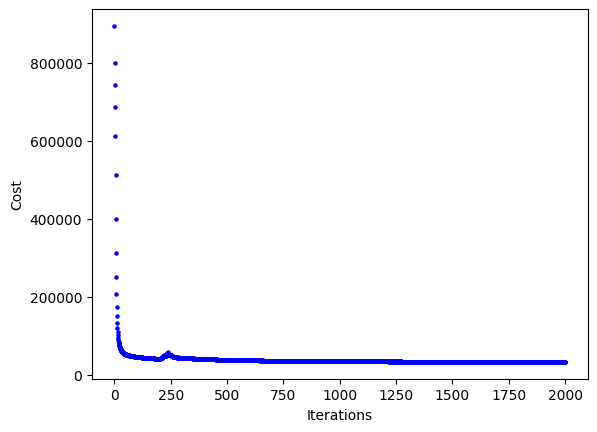

In [105]:
X, Theta, J_hist = fit(Y, R, alpha=0.001, lambd=1, max_iter=2000, eps=.1, step=100, verbose=1)
draw_cost_changes(J_hist)

In [107]:
# Predict, make recomendation
pred = X @ Theta
my_pred = pred[:,0]

print(my_pred.shape)

top_pred = np.argsort(my_pred)[::-1]

print('\nTop recommendations for you:\n')

for i in range(100):
    j = top_pred[i]
    print('Predicting rating {:.2} for movie {} (# {})\n'.format(my_pred[j], df_movie_names.iloc[j], j))

(1682,)

Top recommendations for you:

Predicting rating 7.2 for movie title    Star Wars (1977)
Name: 49, dtype: object (# 49)

Predicting rating 5.4 for movie title    Raiders of the Lost Ark (1981)
Name: 173, dtype: object (# 173)

Predicting rating 5.4 for movie title    Return of the Jedi (1983)
Name: 180, dtype: object (# 180)

Predicting rating 5.3 for movie title    Empire Strikes Back, The (1980)
Name: 171, dtype: object (# 171)

Predicting rating 4.9 for movie title    Independence Day (ID4) (1996)
Name: 120, dtype: object (# 120)

Predicting rating 4.9 for movie title    Jurassic Park (1993)
Name: 81, dtype: object (# 81)

Predicting rating 4.8 for movie title    Forrest Gump (1994)
Name: 68, dtype: object (# 68)

Predicting rating 4.8 for movie title    Mallrats (1995)
Name: 720, dtype: object (# 720)

Predicting rating 4.8 for movie title    Titanic (1997)
Name: 312, dtype: object (# 312)

Predicting rating 4.8 for movie title    Indiana Jones and the Last Crusade (1989)
N

In [ ]:
# some different predictins between example

In [108]:
Y = np.array([
    [5,5,1,1],
    [5,5,1,1],
    [1,1,5,5],
    [1,1,5,5]  
])
R = np.vectorize(lambda x: 1 if x > .5 else 0) (Y)
Y, R

(array([[5, 5, 1, 1],
        [5, 5, 1, 1],
        [1, 1, 5, 5],
        [1, 1, 5, 5]]),
 array([[1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1]]))

In [ ]:
# new user

In [110]:
my_ratings = np.zeros((4, 1))

my_ratings[0] = 5
my_ratings[2] = 1
my_ratings[3] = 1

print('my_ratings\n', my_ratings)

my_ratings
 [[5.]
 [0.]
 [1.]
 [1.]]


In [111]:
# concat train and test sets
print('add my ratings')

Y, R = add_my_ratings(Y, R, my_ratings)

print(Y)

add my ratings
[[5. 5. 5. 1. 1.]
 [0. 5. 5. 1. 1.]
 [1. 1. 1. 5. 5.]
 [1. 1. 1. 5. 5.]]


In [ ]:
# same result

Running gradient descent with alpha= 0.01, lambda= 0.1, eps= 0.001, max_iter= 2000
100: 4.25667042506693
200: 3.8388543308534695
300: 3.5073969292065867
400: 3.244929095765261
500: 3.037307357530345
600: 2.8730966005347396
700: 2.7431287336345984
J_hist[iter_number]=2.6754817708271137


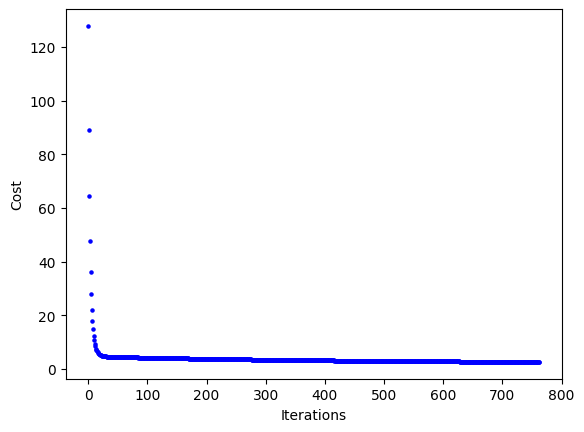

In [112]:
X, Theta, J_hist = fit(Y, R, alpha=0.01, lambd=0.1, max_iter=2000, eps=.001, verbose=1)
draw_cost_changes(J_hist)

In [113]:
# predict
pred = X @ Theta
my_pred = pred[:,0] 
pred # first columns corresponds to my ratings 

array([[4.93179693, 4.96373946, 4.97294368, 1.00741187, 0.99524511],
       [3.74693647, 4.95299586, 4.93823194, 0.99363625, 1.00724028],
       [0.99265197, 0.99964485, 1.00227309, 4.95586195, 4.94939855],
       [1.00267868, 0.99985048, 0.99699061, 4.95009559, 4.94792911]])

In [114]:
for i in range(4):
    print('Predicting rating {:.2} , provided: {}'.format(my_pred[i], my_ratings[i,0]))

Predicting rating 4.9 , provided: 5.0
Predicting rating 3.7 , provided: 0.0
Predicting rating 0.99 , provided: 1.0
Predicting rating 1.0 , provided: 1.0


In [ ]:
# same result

# PS thx for forgotten file movie_ids.txt